# 02 — Method 1: TF-IDF Retrieval (Baseline)
## UniMatch: Arabic Student Advising Chatbot

### Dataset Split
| File | Role | Size |
|------|------|------|
| `faq_train.csv` | Retrieval index | 224 questions |
| `faq_test_long.csv` | Evaluation queries | 224 queries (56×4) |

### Evaluation Protocol
- **Index:** built on `faq_train.csv` → `question` column only
- **Query:** from `faq_test_long.csv` → `query` column (paraphrases)
- **Ground truth:** `answer` column

## Cell 1 — Install

In [1]:
!pip install -q scikit-learn pandas matplotlib

## Cell 2 — Mount Drive & Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR   = '/content/drive/MyDrive/Student_chatbot/'
DATA_DIR   = os.path.join(BASE_DIR, 'data/')
MODEL_DIR  = os.path.join(BASE_DIR, 'models/')
RESULT_DIR = os.path.join(BASE_DIR, 'results/')

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print('Checking required files:')
for f in ['faq_train.csv', 'faq_test_long.csv']:
    path = os.path.join(DATA_DIR, f)
    print(f'  {f:25s} {"✅" if os.path.exists(path) else "❌ MISSING"}')

Mounted at /content/drive
Checking required files:
  faq_train.csv             ✅
  faq_test_long.csv         ✅


## Cell 3 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print('Imports done ✅')

Imports done ✅


## Cell 4 — Load Dataset

In [13]:
# Cell 4 — Load Dataset (FIXED)

# Index = ALL questions (full knowledge base)
df_index = pd.read_csv(os.path.join(DATA_DIR, 'faq_enhanced.csv'))

# Test queries = ALL paraphrases from enhanced dataset
# Long format: one row per paraphrase
long_rows = []
for _, row in df_index.iterrows():
    for col in ['question_alt', 'question_alt2',
                'question_alt3', 'question_alt4']:
        if col in row and pd.notna(row[col]):
            long_rows.append({
                'question': row['question'],
                'answer'  : row['answer'],
                'query'   : row[col],
            })

df_test = pd.DataFrame(long_rows)

print(f'Index (full)  : {len(df_index)} questions ✅')
print(f'Test queries  : {len(df_test)} queries ✅')
print(f'  ({len(df_index)} questions × 4 paraphrases)')
display(df_index.head(3))
display(df_test.head(4))

Index (full)  : 280 questions ✅
Test queries  : 1120 queries ✅
  (280 questions × 4 paraphrases)


,question,answer,question_alt,question_alt2,question_alt3,question_alt4
0,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟,ما تاريخ تأسيس كلية الاقتصاد والأعمال؟,منذ متى تأسست كلية الاقتصاد والأعمال؟
1,ما الهدف من إنشاء كلية الاقتصاد والأعمال؟,تهدف كلية الاقتصاد والأعمال إلى إعداد وتأهيل خ...,ما الغرض الذي أُسست من أجله كلية الاقتصاد والأ...,ما الغاية من إنشاء كلية الاقتصاد والأعمال؟,ما غرض إنشاء كلية الاقتصاد والأعمال؟,لماذا يُقدَّم إنشاء كلية الاقتصاد والأعمال؟
2,كم عدد الأقسام في كلية الاقتصاد والأعمال؟,تضم كلية الاقتصاد والأعمال خمسة أقسام.,كم قسمًا تحتوي كلية الاقتصاد والأعمال؟,ما عدد الأقسام في كلية الاقتصاد والأعمال؟,كم يبلغ عدد الأقسام في كلية الاقتصاد والأعمال؟,كم الأقسام في كلية الاقتصاد والأعمال يوجد؟


,question,answer,query
0,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
1,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
2,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,ما تاريخ تأسيس كلية الاقتصاد والأعمال؟
3,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,منذ متى تأسست كلية الاقتصاد والأعمال؟


## Cell 5 — Build TF-IDF Index

In [14]:
# Build index on train questions ONLY — no leakage
vectorizer = TfidfVectorizer(
    analyzer     = 'char_wb',
    ngram_range  = (2, 4),
    min_df       = 1,
    sublinear_tf = True
)

tfidf_matrix = vectorizer.fit_transform(df_index['question'])

print(f'Vocabulary size : {len(vectorizer.vocabulary_):,}')
print(f'Matrix shape    : {tfidf_matrix.shape}')
print('TF-IDF index built ✅')

Vocabulary size : 4,088
Matrix shape    : (280, 4088)
TF-IDF index built ✅


## Cell 6 — Retrieval Function

In [15]:
def retrieve_tfidf(query, vectorizer, matrix, df_index, top_k=5):
    """
    Retrieve top-k answers using TF-IDF cosine similarity.
    Searches against df_index (train set).
    """
    q_vec   = vectorizer.transform([query])
    scores  = cosine_similarity(q_vec, matrix)[0]
    top_idx = np.argsort(scores)[::-1][:top_k]

    top_k_results = [
        (df_index.iloc[i]['question'], float(scores[i]))
        for i in top_idx
    ]

    best_idx = top_idx[0]
    return (
        df_index.iloc[best_idx]['answer'],
        float(scores[best_idx]),
        df_index.iloc[best_idx]['question'],
        top_k_results
    )

print('Retrieval function defined ✅')

Retrieval function defined ✅


## Cell 7 — Test on Sample Queries

In [16]:
# Take 4 random queries from test set
sample_queries = df_test['query'].sample(4, random_state=42).tolist()

print('TF-IDF Retrieval — Sample Results')
print('='*65)
for q in sample_queries:
    answer, score, matched, _ = retrieve_tfidf(
        q, vectorizer, tfidf_matrix, df_index)
    print(f'\n  Query   : {q}')
    print(f'  Matched : {matched}')
    print(f'  Score   : {score:.4f}')
    print(f'  Answer  : {answer[:80]}...')
print('\n' + '='*65)

TF-IDF Retrieval — Sample Results

  Query   : ما معنى تأجيل الدراسة؟
  Matched : ما المقصود بتأجيل الدراسة؟
  Score   : 0.5906
  Answer  : تأجيل الدراسة هو إيقاف الطالب لدراسته بشكل مؤقّت لفترة محددة وفق أنظمة الجامعة، ...

  Query   : ما الهدف من دراسة تخصص المحاسبة والتدقيق المالي؟
  Matched : ما الغاية من دراسة تخصص المحاسبة والتدقيق المالي؟
  Score   : 0.8549
  Answer  : يهدف تخصص المحاسبة والتدقيق المالي إلى تزويد الخريجين بالمعرفة والكفاءات اللازمة...

  Query   : ما معنى الخدمات الإلكترونية في الجامعة بشكل عام؟
  Matched : ما المقصود بالخدمات الإلكترونية في الجامعة بشكل عام؟
  Score   : 0.7867
  Answer  : الخدمات الإلكترونية هي نظام متكامل تقدمه الجامعة عبر الإنترنت يهدف إلى تسهيل حيا...

  Query   : هل يمكنك الإجابة عن: ما هي خطوات التسجيل للطالب الجديد؟
  Matched : ما هي خطوات التسجيل للطالب الجديد؟
  Score   : 0.9042
  Answer  : تبدأ الخطوات بتقديم طلب الالتحاق، ثم قبول الطالب، بعدها دفع الرسوم، وأخيرًا تسجي...



## Cell 8 — Evaluation Function

In [17]:
def evaluate_tfidf(df_test, vectorizer, matrix, df_index):
    """
    Evaluate TF-IDF on test queries.

    df_test   : test queries — columns: [question, answer, query]
    vectorizer: fitted TF-IDF vectorizer
    matrix    : TF-IDF matrix of df_index questions
    df_index  : train FAQ pairs (retrieval index)

    Metrics: Accuracy@1, Accuracy@3, MRR, Avg Score, Avg Time
    """
    correct_at1, correct_at3 = [], []
    rr_list, time_list       = [], []
    all_scores               = []

    for _, row in df_test.iterrows():
        query       = row['query']       # paraphrase query
        true_answer = row['answer']      # ground truth

        t_start = time.time()
        q_vec   = vectorizer.transform([query])
        scores  = cosine_similarity(q_vec, matrix)[0]
        elapsed = (time.time() - t_start) * 1000

        top5_idx = np.argsort(scores)[::-1][:5]
        top5_ans = [df_index.iloc[i]['answer'] for i in top5_idx]

        # Accuracy@1
        correct_at1.append(top5_ans[0].strip() == true_answer.strip())

        # Accuracy@3
        correct_at3.append(
            true_answer.strip() in [a.strip() for a in top5_ans[:3]])

        # MRR
        rr = 0
        for rank, ans in enumerate(top5_ans, 1):
            if ans.strip() == true_answer.strip():
                rr = 1 / rank
                break
        rr_list.append(rr)
        time_list.append(elapsed)
        all_scores.append(float(scores[top5_idx[0]]))

    return {
        'Accuracy@1'   : np.mean(correct_at1) * 100,
        'Accuracy@3'   : np.mean(correct_at3) * 100,
        'MRR'          : np.mean(rr_list),
        'Avg Score'    : np.mean(all_scores),
        'Avg Time (ms)': np.mean(time_list),
        'details'      : {
            'correct_at1': correct_at1,
            'scores'     : all_scores,
            'times'      : time_list,
        }
    }

print('Evaluation function defined ✅')

Evaluation function defined ✅


## Cell 9 — Run Evaluation

In [18]:
print('Running TF-IDF evaluation...')
print(f'  Index size : {len(df_index)} questions')
print(f'  Test size  : {len(df_test)} queries (4 paraphrases × {len(df_test)//4} questions)')

metrics = evaluate_tfidf(df_test, vectorizer, tfidf_matrix, df_index)

print('\n' + '='*50)
print('  TF-IDF EVALUATION RESULTS')
print('='*50)
print(f'  Accuracy@1    : {metrics["Accuracy@1"]:.2f}%')
print(f'  Accuracy@3    : {metrics["Accuracy@3"]:.2f}%')
print(f'  MRR           : {metrics["MRR"]:.4f}')
print(f'  Avg Score     : {metrics["Avg Score"]:.4f}')
print(f'  Avg Time (ms) : {metrics["Avg Time (ms)"]:.2f}')
print(f'  Index size    : {len(df_index)}')
print(f'  Test queries  : {len(df_test)}')
print('='*50)

Running TF-IDF evaluation...
  Index size : 280 questions
  Test size  : 1120 queries (4 paraphrases × 280 questions)

  TF-IDF EVALUATION RESULTS
  Accuracy@1    : 90.09%
  Accuracy@3    : 98.04%
  MRR           : 0.9399
  Avg Score     : 0.8008
  Avg Time (ms) : 1.59
  Index size    : 280
  Test queries  : 1120


## Cell 10 — Score Distribution Plot

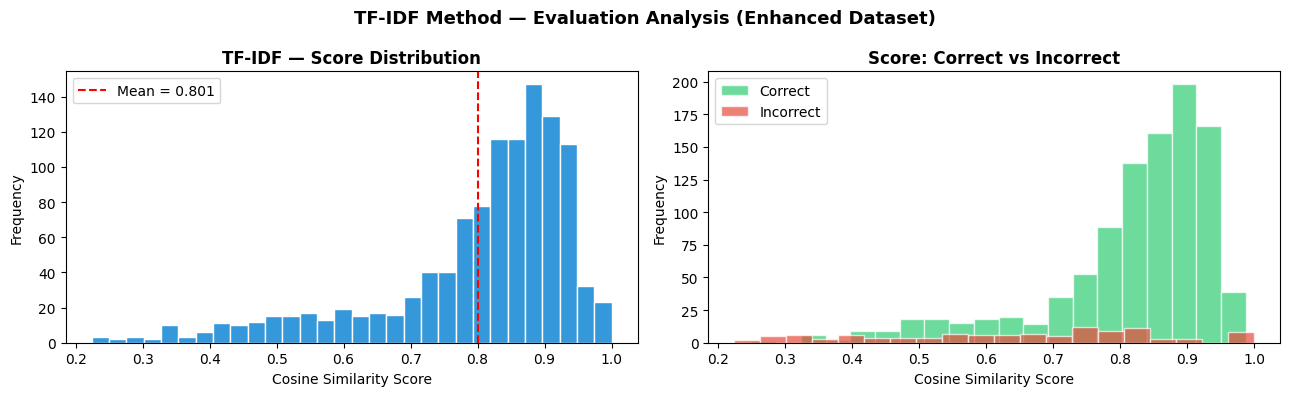

Plot saved ✅


In [19]:
scores_list      = metrics['details']['scores']
correct_list     = metrics['details']['correct_at1']
correct_scores   = [s for s, c in zip(scores_list, correct_list) if c]
incorrect_scores = [s for s, c in zip(scores_list, correct_list) if not c]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(scores_list, bins=30, color='#3498db', edgecolor='white')
axes[0].axvline(np.mean(scores_list), color='red', linestyle='--',
                label=f'Mean = {np.mean(scores_list):.3f}')
axes[0].set_title('TF-IDF — Score Distribution', fontweight='bold')
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(correct_scores,   bins=20, alpha=0.7,
             color='#2ecc71', edgecolor='white', label='Correct')
axes[1].hist(incorrect_scores, bins=20, alpha=0.7,
             color='#e74c3c', edgecolor='white', label='Incorrect')
axes[1].set_title('Score: Correct vs Incorrect', fontweight='bold')
axes[1].set_xlabel('Cosine Similarity Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('TF-IDF Method — Evaluation Analysis (Enhanced Dataset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'tfidf_score_distribution_v2.png'), dpi=150)
plt.show()
print('Plot saved ✅')

## Cell 11 — Error Analysis

In [20]:
errors = []
for _, row in df_test.iterrows():
    query       = row['query']
    true_answer = row['answer']
    answer, score, matched_q, _ = retrieve_tfidf(
        query, vectorizer, tfidf_matrix, df_index)
    if answer.strip() != true_answer.strip():
        errors.append({
            'query'      : query,
            'matched_q'  : matched_q,
            'score'      : round(score, 4),
            'true_answer': true_answer[:60],
            'pred_answer': answer[:60],
        })

errors_df = pd.DataFrame(errors)
print(f'Total errors : {len(errors_df)} / {len(df_test)}')
print(f'Error rate   : {len(errors_df)/len(df_test)*100:.1f}%')
if len(errors_df) > 0:
    print('\nSample errors (lowest score):')
    display(errors_df.nsmallest(5, 'score')[['query', 'matched_q', 'score']])

Total errors : 111 / 1120
Error rate   : 9.9%

Sample errors (lowest score):


,query,matched_q,score
67,أهلًا,ما أهم مادة في الكلية؟,0.2238
71,هل يشترط امتلاك مهارات رياضية متقدمة للالتحاق ...,هل تحتاج الخدمات الإلكترونية إلى مهارات خاصة؟,0.2436
91,هل يُمكن أن يُحرَم الطالب من منحته؟,متى يتم فصل الطالب من الجامعة؟,0.2697
98,هل تتمتع الخدمات الرقمية بمستوى كافٍ من الأمان؟,هل يمكن للطالب إعادة امتحان المستوى إذا رسب؟,0.2723
77,هل تشمل الاختبارات تطبيقًا عمليًا؟,هل تشمل المنح كل التخصصات؟,0.2803


## Cell 12 — Save Results

In [21]:
# Save vectorizer and matrix
with open(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(vectorizer, f)
with open(os.path.join(MODEL_DIR, 'tfidf_matrix.pkl'), 'wb') as f:
    pickle.dump(tfidf_matrix, f)

# Save metrics
metrics_df = pd.DataFrame([{
    'Method'       : 'TF-IDF',
    'Accuracy@1'   : round(metrics['Accuracy@1'], 2),
    'Accuracy@3'   : round(metrics['Accuracy@3'], 2),
    'MRR'          : round(metrics['MRR'], 4),
    'Avg Score'    : round(metrics['Avg Score'], 4),
    'Avg Time (ms)': round(metrics['Avg Time (ms)'], 2),
    'Index Size'   : len(df_index),
    'Test Queries' : len(df_test),
}])
metrics_df.to_csv(
    os.path.join(RESULT_DIR, 'tfidf_results_v2.csv'), index=False)
if len(errors_df) > 0:
    errors_df.to_csv(
        os.path.join(RESULT_DIR, 'tfidf_errors_v2.csv'), index=False)

print('='*50)
print('  SAVED FILES')
print('='*50)
print(f'  models/tfidf_vectorizer.pkl')
print(f'  models/tfidf_matrix.pkl')
print(f'  results/tfidf_results_v2.csv')
print('='*50)
display(metrics_df)
print(f'\nNext → 03_method2_BERT.ipynb')

  SAVED FILES
  models/tfidf_vectorizer.pkl
  models/tfidf_matrix.pkl
  results/tfidf_results_v2.csv


,Method,Accuracy@1,Accuracy@3,MRR,Avg Score,Avg Time (ms),Index Size,Test Queries
0,TF-IDF,90.09,98.04,0.9399,0.8008,1.59,280,1120



Next → 03_method2_BERT.ipynb
